In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install transformers

In [4]:
import numpy as np # used for handling numbers
import pandas as pd # used for handling the dataset
from sklearn.impute import SimpleImputer # used for handling missing data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # used for encoding categorical data
from sklearn.model_selection import train_test_split # used for splitting training and testing data
from sklearn.preprocessing import StandardScaler # used for feature scaling

In [5]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
device

'cuda'

In [6]:
import pandas as pd
input = pd.read_csv('/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/preprocessedInput.csv', encoding='utf-8')
val_df = pd.read_csv('/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/preprocessedValInput.csv', encoding='utf-8')

In [7]:
input.head()

,episode,speakers,utterances,emotions,cleaned_utterances,hindi_utterances,english_utterances
0,roseshantstobeadopted.wmv,maya,kya kya bhar ke rakha hai indravadan ne is gha...,disgust,kya kya bhar ke rakha hai indravadan ne ghar m...,क्य क्य भर् के रख है इन्द्रवदन् ने इस् घर् मेइ...,What does Indravadan keep in the house? Indrav...
1,roseshantstobeadopted.wmv,indu,"ok, chalo rosesh chalo bahar",contempt,ok chalo rosesh chalo bahar,"ओक्, चलो रोसेश् चलो बहर्","ok, let's rise, let's spring"
2,roseshantstobeadopted.wmv,rosesh,momma! hath chhodiye dad!,anger,momma hath chhodiye dad,मोम्म! हथ् छोदिये दद्!,Momma! Hath Chodiye Dad!
3,roseshantstobeadopted.wmv,indu,dekho maya ya na bol raha hai! fir tum hi kaho...,neutral,dekho maya ya na bol raha hai fir tum hi kahog...,देखो मय य न बोल् रह है! फ़िर् तुम् हि कहोगि फ़ल्...,Look Maya or I am not speaking! Then you will ...
4,roseshantstobeadopted.wmv,maya,"indravadan, tum kitne salo se ye joke maar rah...",neutral,indravadan tum kitne salo se ye joke maar rahe...,"इन्द्रवदन्, तुम् कित्ने सलो से ये जोके मार् रह...","Indravadan, for how many years have you been t..."


In [8]:
input['utterance_id'] = range(1, len(input) + 1)
val_df['utterance_id'] = range(1, len(val_df) + 1)

In [9]:
train = input[['utterance_id', 'english_utterances', 'emotions']]
val = val_df[['utterance_id', 'english_utterances', 'emotions']]

<Axes: >

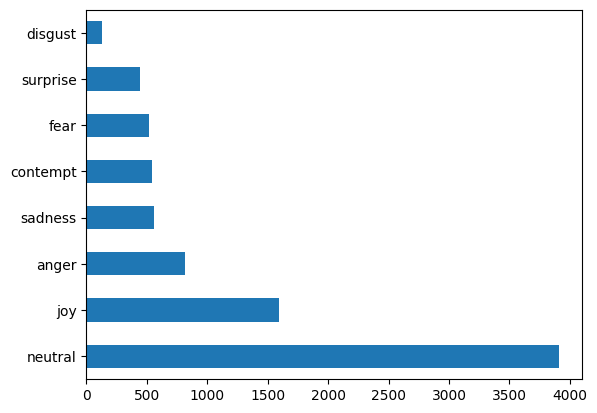

In [10]:
train['emotions'].value_counts().plot(kind="barh")

In [11]:
train.isnull().sum().sum()

0

In [12]:
emotions = train['emotions'].unique().tolist()
emotions_val = val['emotions'].unique().tolist()
emotions = [s.strip() for s in emotions ]
emotions_val = [s.strip() for s in emotions_val ]

In [13]:
for key, value in enumerate(emotions):
    print(value)

disgust
contempt
anger
neutral
joy
sadness
fear
surprise


In [14]:
NUM_LABELS= len(emotions)

id2label={id:label for id,label in enumerate(emotions)}

label2id={label:id for id,label in enumerate(emotions)}

In [15]:
label2id

{'disgust': 0,
 'contempt': 1,
 'anger': 2,
 'neutral': 3,
 'joy': 4,
 'sadness': 5,
 'fear': 6,
 'surprise': 7}

In [16]:
id2label

{0: 'disgust',
 1: 'contempt',
 2: 'anger',
 3: 'neutral',
 4: 'joy',
 5: 'sadness',
 6: 'fear',
 7: 'surprise'}

In [17]:
train["labels"]=train.emotions.map(lambda x: label2id[x.strip()])
val["labels"]=val.emotions.map(lambda x: label2id[x.strip()])

<ipython-input-17-c1baa4402f96>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["labels"]=train.emotions.map(lambda x: label2id[x.strip()])
<ipython-input-17-c1baa4402f96>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val["labels"]=val.emotions.map(lambda x: label2id[x.strip()])


In [18]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained('bert-large-uncased')
model = AutoModelForSequenceClassification.from_pretrained("bert-large-uncased", num_labels=NUM_LABELS, id2label=id2label, label2id=label2id)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,

In [20]:
train.labels.unique()

array([0, 1, 2, 3, 4, 5, 6, 7])

In [21]:
# SIZE= train.shape[0]

train_texts= list(train.english_utterances)

val_texts=   list(val.english_utterances)

# test_texts=  list(train.hindi_utterances[(3*SIZE)//4:])

train_labels= list(train.labels)

val_labels=   list(val.labels)

# test_labels=  list(train.labels[(3*SIZE)//4:])

In [22]:
len(train_texts), len(val_texts)

(8506, 1354)

In [23]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings  = tokenizer(val_texts, truncation=True, padding=True)
# test_encodings = tokenizer(test_texts, truncation=True, padding=True)

In [24]:
from torch.utils.data import Dataset

class DataLoader(Dataset):
    """
    Custom Dataset class for handling tokenized text data and corresponding labels.
    Inherits from torch.utils.data.Dataset.
    """
    def __init__(self, encodings, labels):
        """
        Initializes the DataLoader class with encodings and labels.

        Args:
            encodings (dict): A dictionary containing tokenized input text data
                              (e.g., 'input_ids', 'token_type_ids', 'attention_mask').
            labels (list): A list of integer labels for the input text data.
        """
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        """
        Returns a dictionary containing tokenized data and the corresponding label for a given index.

        Args:
            idx (int): The index of the data item to retrieve.

        Returns:
            item (dict): A dictionary containing the tokenized data and the corresponding label.
        """
        # Retrieve tokenized data for the given index
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Add the label for the given index to the item dictionary
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        """
        Returns the number of data items in the dataset.

        Returns:
            (int): The number of data items in the dataset.
        """
        return len(self.labels)

In [25]:
train_dataloader = DataLoader(train_encodings, train_labels)

val_dataloader = DataLoader(val_encodings, val_labels)

# test_dataset = DataLoader(test_encodings, test_labels)

In [26]:
from transformers import TrainingArguments, Trainer

In [27]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    """
    Computes accuracy, F1, precision, and recall for a given set of predictions.

    Args:
        pred (obj): An object containing label_ids and predictions attributes.
            - label_ids (array-like): A 1D array of true class labels.
            - predictions (array-like): A 2D array where each row represents
              an observation, and each column represents the probability of
              that observation belonging to a certain class.

    Returns:
        dict: A dictionary containing the following metrics:
            - Accuracy (float): The proportion of correctly classified instances.
            - F1 (float): The macro F1 score, which is the harmonic mean of precision
              and recall. Macro averaging calculates the metric independently for
              each class and then takes the average.
            - Precision (float): The macro precision, which is the number of true
              positives divided by the sum of true positives and false positives.
            - Recall (float): The macro recall, which is the number of true positives
              divided by the sum of true positives and false negatives.
    """
    # Extract true labels from the input object
    labels = pred.label_ids

    # Obtain predicted class labels by finding the column index with the maximum probability
    preds = pred.predictions.argmax(-1)

    # Compute macro precision, recall, and F1 score using sklearn's precision_recall_fscore_support function
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')

    # Calculate the accuracy score using sklearn's accuracy_score function
    acc = accuracy_score(labels, preds)

    # Return the computed metrics as a dictionary
    return {
        'Accuracy': acc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    }

In [28]:
!pip install transformers[torch]

In [29]:
training_args = TrainingArguments(
    # The output directory where the model predictions and checkpoints will be written
    output_dir='/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/Task1_Predictions_English',
    do_train=True,
    do_eval=True,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    # Number of steps used for a linear warmup
    warmup_steps=0,
    weight_decay=0.1,
    logging_strategy='steps',
   # TensorBoard log directory
    logging_dir='/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/Task1_Predictions_English/multi-class-logs',
    logging_steps=50,
    evaluation_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    fp16=True,
    load_best_model_at_end=True
)

In [30]:
trainer = Trainer(
    # the pre-trained model that will be fine-tuned
    model=model,
     # training arguments that we defined above
    args=training_args,
    train_dataset=train_dataloader,
    eval_dataset=val_dataloader,
    compute_metrics= compute_metrics
)

In [31]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
50,1.729800,1.652453,0.463811,0.079293,0.058278,0.124013
100,1.655600,1.651864,0.468242,0.090155,0.133469,0.130287
150,1.622400,1.613597,0.441654,0.124752,0.138743,0.153753
200,1.647100,1.651477,0.467504,0.079643,0.058438,0.125000
250,1.675600,1.650713,0.468242,0.080810,0.121024,0.125548
300,1.627600,1.661221,0.467504,0.079643,0.058438,0.125000
350,1.661400,1.647477,0.467504,0.079643,0.058438,0.125000
400,1.641400,1.619159,0.467504,0.079643,0.058438,0.125000
450,1.669500,1.623688,0.459380,0.093160,0.147180,0.130516
500,1.626700,1.622686,0.468242,0.081651,0.183481,0.125992


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

TrainOutput(global_step=1596, training_loss=1.634365186954202, metrics={'train_runtime': 1977.9242, 'train_samples_per_second': 12.901, 'train_steps_per_second': 0.807, 'total_flos': 7849755120044448.0, 'train_loss': 1.634365186954202, 'epoch': 3.0})

In [32]:
q=[trainer.evaluate(eval_dataset=train) for train in [train_dataloader, val_dataloader]]

pd.DataFrame(q, index=["train","val"]).iloc[:,:5]

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,eval_loss,eval_Accuracy,eval_F1,eval_Precision,eval_Recall
train,1.552133,0.476252,0.122041,0.211311,0.146669
val,1.585027,0.468242,0.119742,0.156041,0.143698


In [33]:
def predict(text):
    """
    Predicts the class label for a given input text

    Args:
        text (str): The input text for which the class label needs to be predicted.

    Returns:
        probs (torch.Tensor): Class probabilities for the input text.
        pred_label_idx (torch.Tensor): The index of the predicted class label.
        pred_label (str): The predicted class label.
    """
    # Tokenize the input text and move tensors to the GPU if available
    inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to("cuda")

    # Get model output (logits)
    outputs = model(**inputs)

    probs = outputs[0].softmax(1)
    """ Explanation outputs: The BERT model returns a tuple containing the output logits (and possibly other elements depending on the model configuration). In this case, the output logits are the first element in the tuple, which is why we access it using outputs[0].

    outputs[0]: This is a tensor containing the raw output logits for each class. The shape of the tensor is (batch_size, num_classes) where batch_size is the number of input samples (in this case, 1, as we are predicting for a single input text) and num_classes is the number of target classes.

    softmax(1): The softmax function is applied along dimension 1 (the class dimension) to convert the raw logits into class probabilities. Softmax normalizes the logits so that they sum to 1, making them interpretable as probabilities. """

    # Get the index of the class with the highest probability
    # argmax() finds the index of the maximum value in the tensor along a specified dimension.
    # By default, if no dimension is specified, it returns the index of the maximum value in the flattened tensor.
    pred_label_idx = probs.argmax()

    # Now map the predicted class index to the actual class label
    # Since pred_label_idx is a tensor containing a single value (the predicted class index),
    # the .item() method is used to extract the value as a scalar
    pred_label = model.config.id2label[pred_label_idx.item()]

    # return probs, pred_label_idx, pred_label
    return pred_label

In [34]:
model_path = "tae898/emoberta-base"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

('tae898/emoberta-base/tokenizer_config.json',
 'tae898/emoberta-base/special_tokens_map.json',
 'tae898/emoberta-base/vocab.txt',
 'tae898/emoberta-base/added_tokens.json',
 'tae898/emoberta-base/tokenizer.json')

In [35]:
results = []
for index, row in val.iterrows():
    result = predict(row['english_utterances'])
    results.append(result)

val['predicted_emotions'] = results

<ipython-input-35-53abd4b3aac7>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['predicted_emotions'] = results


In [36]:
val

,utterance_id,english_utterances,emotions,labels,predicted_emotions
0,1,What are you doing Rosesh? India is your count...,neutral,3,neutral
1,2,hahaha read the book rosesh baby or read the b...,neutral,3,neutral
2,3,"Poetry is good but thought is not good, villai...",neutral,3,neutral
3,4,"It's wrong, but mom told you to brush twice an...",contempt,1,neutral
4,5,galat tha per,neutral,3,neutral
...,...,...,...,...,...
1349,1350,shore shore shore Only 4 days left or all the ...,fear,6,neutral
1350,1351,Yes but mom will finalize one of the four.,neutral,3,neutral
1351,1352,mummy ji doesn't like any of us,sadness,5,joy
1352,1353,rosesh ko?,neutral,3,neutral


In [37]:
from sklearn.metrics import classification_report
print(classification_report(val.emotions,val.predicted_emotions,digits=4))

              precision    recall  f1-score   support

       anger     0.3333    0.0508    0.0882       118
    contempt     0.0000    0.0000    0.0000        74
     disgust     0.0000    0.0000    0.0000        21
        fear     0.0000    0.0000    0.0000        88
         joy     0.4419    0.1667    0.2420       228
     neutral     0.4731    0.9321    0.6277       633
     sadness     0.0000    0.0000    0.0000       126
    surprise     0.0000    0.0000    0.0000        66

    accuracy                         0.4682      1354
   macro avg     0.1560    0.1437    0.1197      1354
weighted avg     0.3246    0.4682    0.3419      1354



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [38]:
# import torch
# import transformers
# from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# model_path = "bert-base-multilingual-cased"
# model = BertForSequenceClassification.from_pretrained(model_path)
# tokenizer= BertTokenizer.from_pretrained(model_path)
# nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

In [39]:
val.to_csv("/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/emoBERTa_predictions.csv", index=False)